# Rapid Adiabatic Passage Simulation

This notebook demonstrates the `rap_simulation` package for simulating rapid adiabatic passage (RAP) in Rubidium-87 atoms using QuTiP.

## Contents
1. Basic Simulation
2. Visualizing Results
3. Bloch Sphere Animation
4. Adiabaticity Analysis
5. Parameter Sweeps
6. Comparing Pulse Shapes


In [1]:
# Add parent directory to path for development
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

# Import from our package
from rap_simulation import (
    Rubidium87,
    RapidAdiabaticPassage,
    SimulationParams,
    adiabaticity_criterion,
)
from rap_simulation.visualization import (
    plot_probabilities,
    plot_pulse_and_detuning,
    plot_expectation_values,
    plot_adiabaticity,
    plot_combined,
    plot_bloch_trajectory,
    animate_bloch,
)
from rap_simulation.scans import sweep_time_scan, frequency_span_scan
from rap_simulation.pulses import list_pulses
from rap_simulation.detuning import list_detunings

# For inline animations
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline


## 1. Basic Simulation

Let's set up a simple RAP simulation for Rb-87 atoms.


In [2]:
# Create the atom
atom = Rubidium87()
print(f"Atom: {atom.name}")
print(f"Clock transition frequency: {atom.transition_frequency/1e9:.6f} GHz")


Atom: Rb-87
Clock transition frequency: 6.834683 GHz


In [3]:
# Create simulation parameters using the convenience method
params = SimulationParams.for_rb87_clock(
    T=1e-3,              # 1 ms total time
    dt=1e-6,             # 1 µs time step
    rabi_freq_hz=10000,  # 10 kHz Rabi frequency
    freq_span_hz=40000,  # 40 kHz frequency span
    sweep_time=0.3e-3,   # 0.3 ms half-sweep time
)

print(f"Total time: {params.T*1e3:.1f} ms")
print(f"Sweep time: {params.sweep_time*1e3:.2f} ms")
print(f"Rabi frequency: {params.omega/(2*np.pi)/1e3:.1f} kHz")


Total time: 1.0 ms
Sweep time: 0.30 ms
Rabi frequency: 10.0 kHz


In [4]:
# List available pulse shapes and detuning profiles
print("Available pulse shapes:", list_pulses())
print("Available detuning profiles:", list_detunings())


Available pulse shapes: ['constant', 'gaussian', 'lorentzian', 'hyper_secant']
Available detuning profiles: ['linear', 'tanh', 'quadratic']


In [5]:
# Run the simulation
rap = RapidAdiabaticPassage(atom, params)
result = rap.run(pulse="hyper_secant", detuning="linear")

print(f"\nSimulation complete!")
print(f"Final transfer probability: {result.final_p1:.4f}")
print(f"Maximum P1 achieved: {result.max_p1:.4f}")



Simulation complete!
Final transfer probability: 0.9806
Maximum P1 achieved: 0.9997


## 2. Visualizing Results


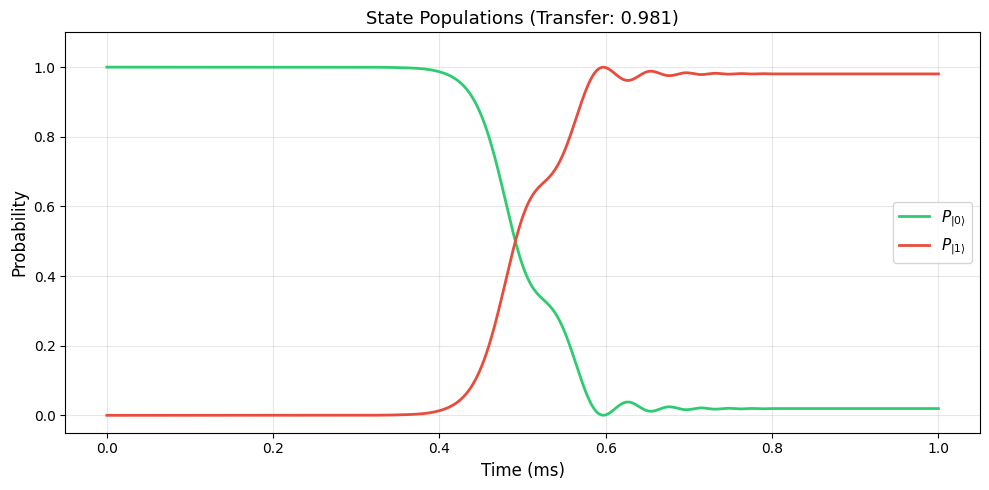

In [6]:
# Plot state probabilities
fig = plot_probabilities(result, time_unit="ms")


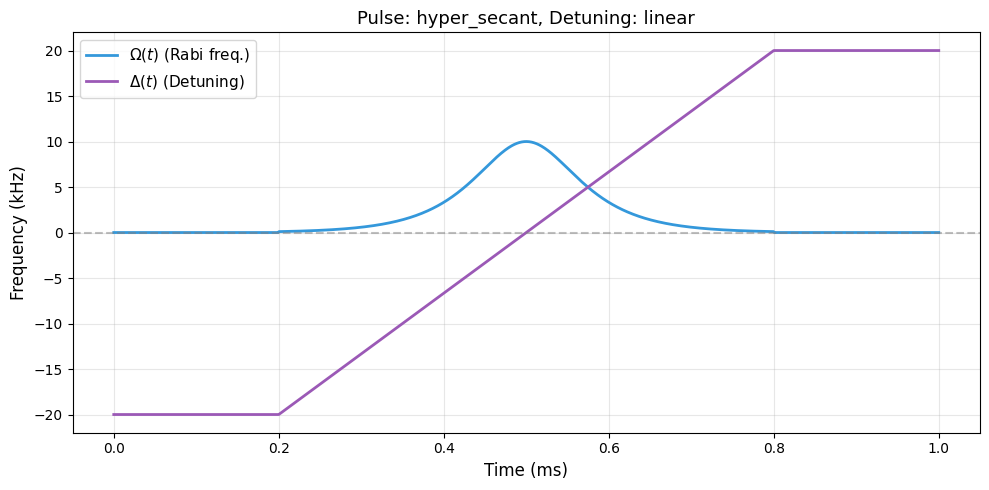

In [7]:
# Plot pulse shape and detuning
fig = plot_pulse_and_detuning(result, time_unit="ms", freq_unit="kHz")


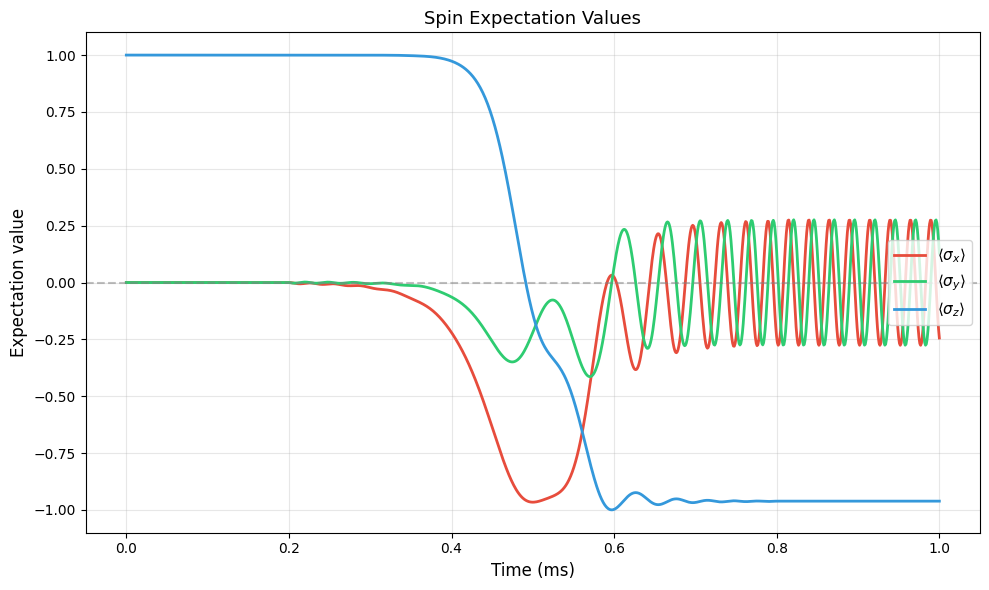

In [8]:
# Plot expectation values using QuTiP's expect()
fig = plot_expectation_values(result, time_unit="ms")


## 3. Bloch Sphere Visualization

Using QuTiP's built-in Bloch class for visualization.


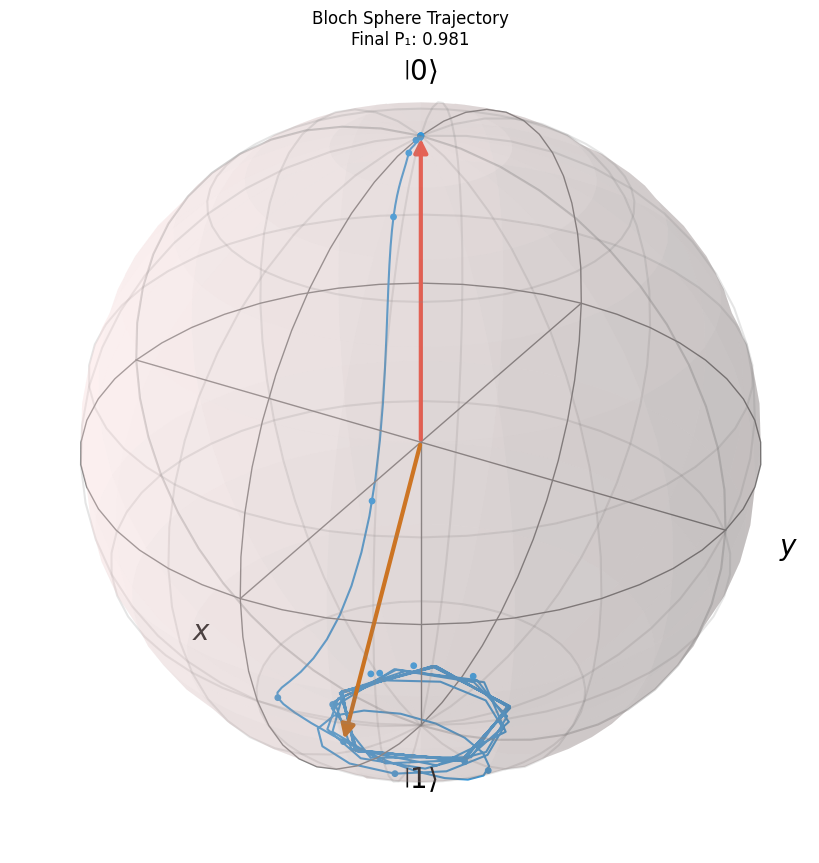

In [9]:
# Static Bloch sphere trajectory
fig, bloch = plot_bloch_trajectory(result)


In [ ]:
# Animated Bloch sphere (uncomment to run - may take a moment)
# ani = animate_bloch(result, fps=20, duration=3.0)


## 4. Adiabaticity Analysis

The adiabatic condition requires that the rate of change of the driving field direction is much slower than the effective Rabi frequency.


In [10]:
# Calculate adiabaticity criterion
analysis = adiabaticity_criterion(
    params,
    pulse_name="hyper_secant",
    detuning_name="linear",
)

print(f"Is adiabatic: {analysis.is_adiabatic}")
print(f"Max criterion value: {analysis.max_criterion:.4f}")
print(f"Mean criterion value: {analysis.mean_criterion:.6f}")


Is adiabatic: False
Max criterion value: 0.3250
Mean criterion value: 0.060910


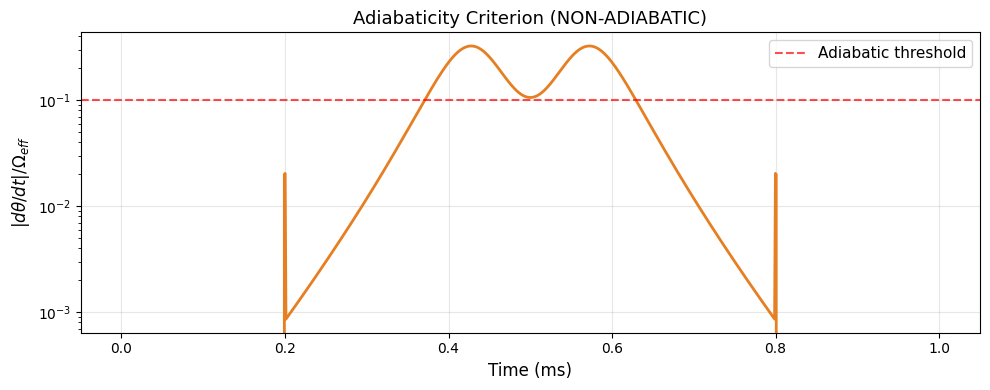

In [11]:
# Plot adiabaticity criterion
fig = plot_adiabaticity(analysis, time_unit="ms")


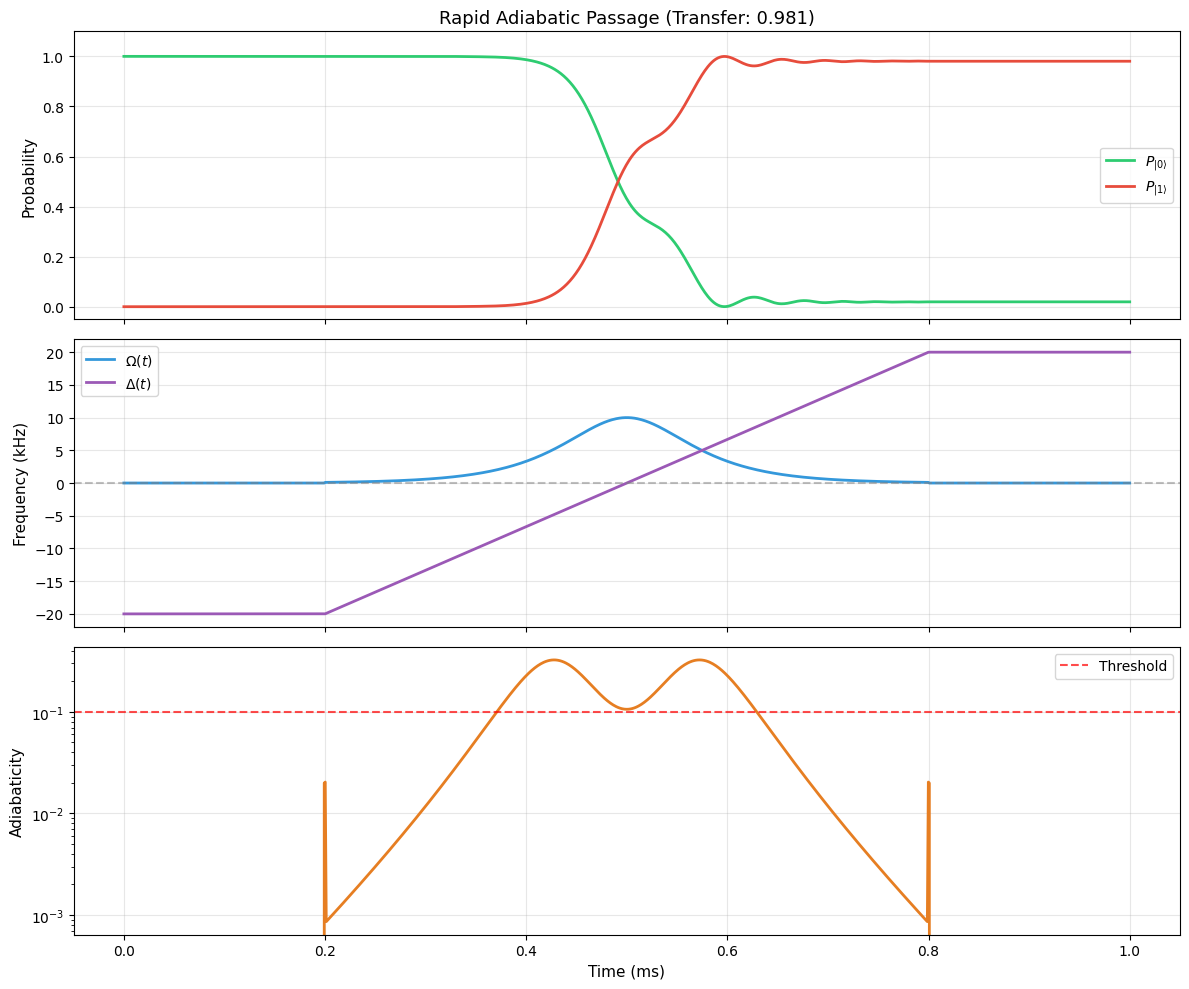

In [12]:
# Combined plot with all information
fig = plot_combined(result, analysis, time_unit="ms")


## 5. Parameter Sweeps

Let's scan the sweep time to find optimal parameters.


In [13]:
# Sweep time scan
sweep_result = sweep_time_scan(
    atom=atom,
    base_params=params,
    t_start=0.1e-3,  # 0.1 ms
    t_end=1.0e-3,    # 1.0 ms
    n_points=20,
    pulse="hyper_secant",
    detuning="linear",
    constant_freq_span=40000,  # Keep 40 kHz span constant
)

print(f"\nOptimal sweep time: {sweep_result.optimal_value*1e3:.3f} ms")
print(f"Maximum P1: {sweep_result.optimal_p1:.4f}")


Sweep time scan: 100%|██████████| 20/20 [00:00<00:00, 29.46it/s]


Optimal sweep time: 0.811 ms
Maximum P1: 1.0000


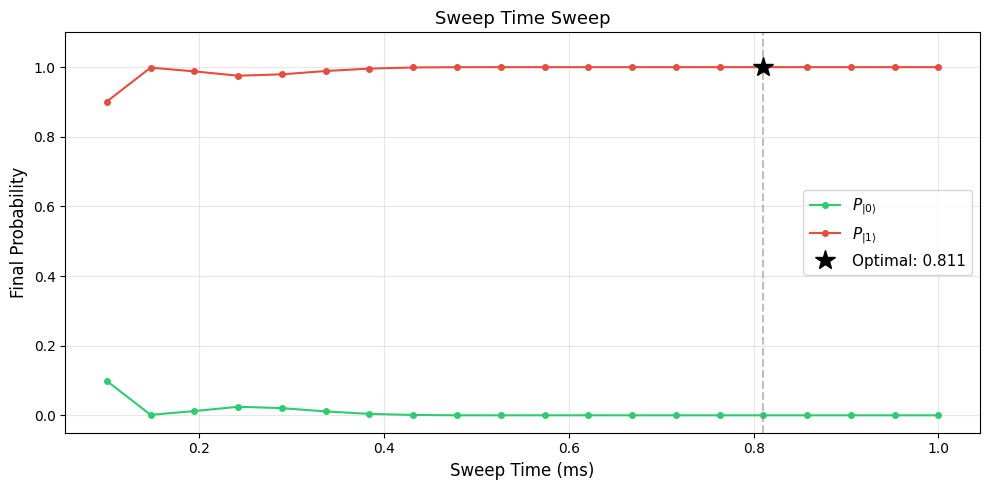

In [14]:
# Plot sweep results
from rap_simulation.visualization.plots import plot_sweep_results

fig = plot_sweep_results(
    sweep_result.parameter_values * 1e3,  # Convert to ms
    sweep_result.p0_final,
    sweep_result.p1_final,
    parameter_name="Sweep Time",
    parameter_unit="ms",
)


## 6. Comparing Pulse Shapes

Let's compare different pulse shapes for the same parameters.


In [15]:
from rap_simulation.scans import compare_pulse_shapes

# Compare all pulse shapes
comparison = compare_pulse_shapes(atom, params)

print("Transfer efficiency by pulse shape:")
for pulse_name, p1 in sorted(comparison.items(), key=lambda x: -x[1]):
    print(f"  {pulse_name}: {p1:.4f}")


Transfer efficiency by pulse shape:
  gaussian: 0.9999
  hyper_secant: 0.9806
  lorentzian: 0.9740
  constant: 0.9301


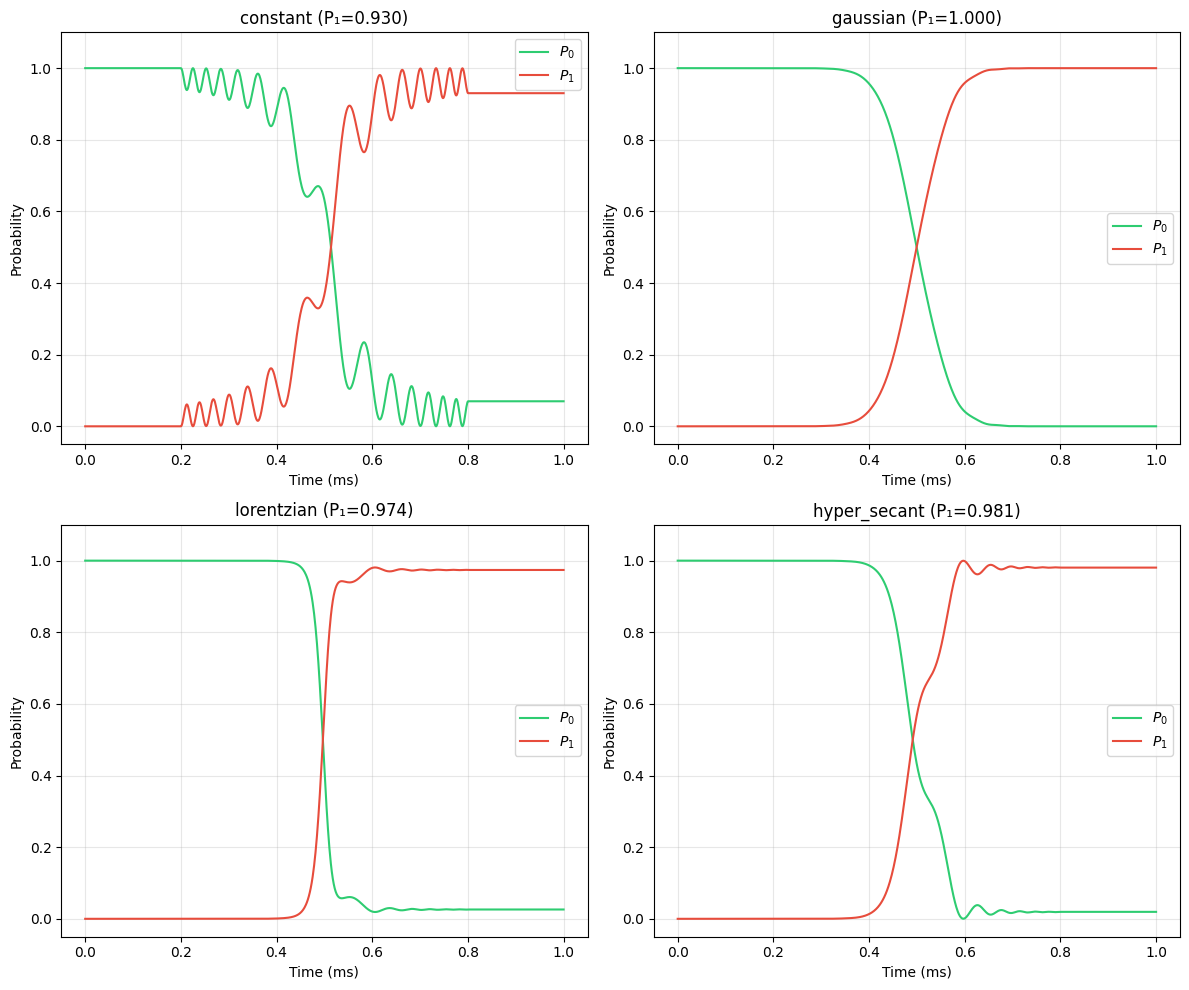

In [16]:
# Visual comparison of all pulse shapes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pulse_name in zip(axes.flat, list_pulses()):
    result = rap.run(pulse=pulse_name, detuning="linear")
    times = result.times * 1e3
    
    ax.plot(times, result.p0, label=r'$P_0$', color='#2ecc71')
    ax.plot(times, result.p1, label=r'$P_1$', color='#e74c3c')
    ax.set_title(f'{pulse_name} (P₁={result.final_p1:.3f})')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()


## Summary

This package provides:

- **Atom classes**: `Rubidium87` with physical constants and Zeeman shift calculations
- **Pulse shapes**: Constant, Gaussian, Lorentzian, Hyperbolic secant (extensible via registry)
- **Detuning profiles**: Linear, Tanh, Quadratic (extensible via registry)
- **Simulation**: `RapidAdiabaticPassage` class using QuTiP's `sesolve`
- **Analysis**: Adiabaticity criteria, Bloch trajectory analysis
- **Visualization**: Probability plots, Bloch sphere (using QuTiP), animations
- **Parameter sweeps**: Sweep time, frequency span, spectroscopy scans
